<a href="https://colab.research.google.com/github/thaynnayara/ADS-Inteligencia_Artificial/blob/main/Isolation_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nesta atividade, você atuará como analista de dados responsável por identificar perfis de acesso potencialmente anômalos em um sistema, utilizando técnicas de Inteligência Artificial. Você deverá aplicar técnicas de detecção de anomalias para identificar acessos fora do padrão em logs de sistemas, utilizando o algoritmo Isolation Forest, e interpretar criticamente os resultados obtidos.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [6]:
# 1 - Carregar o dataset correto
df = pd.read_csv('acessos_sistema.csv')
print("Linhas iniciais")
print(df.head())

Linhas iniciais
   hora_acesso  duracao_sessao_min  numero_tentativas_login  \
0            9                  35                        1   
1           10                  40                        1   
2           11                  25                        1   
3           14                  50                        1   
4           15                  45                        1   

   ip_diferente_habitual  quantidade_paginas_acessadas  
0                      0                            12  
1                      0                            15  
2                      0                             9  
3                      0                            18  
4                      0                            16  


In [7]:
# 2 - Selecionar as variáveis de interesse para o perfil de acesso

colunas = [
    'hora_acesso',
    'duracao_sessao_min',
    'numero_tentativas_login',
    'ip_diferente_habitual',
    'quantidade_paginas_acessadas'
]

x = df[colunas]

In [8]:
# 3 - Padronização dos dados
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(x)

In [11]:
# 4 - Treinamento
# Definição da contaminação em 0.1 - 10%
model = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42
)
model.fit(X_padronizado)

IsolationForest(contamination=0.1, random_state=42)

In [13]:
# 5 - Predição de anomalias (-1 = anomalia | 1 = normal)
df['anomaly'] = model.predict(X_padronizado)

# Score da anomalia (quanto menor/mais negativo, mais isolado e anômalo o ponto é)
df['score'] = model.decision_function(X_padronizado)

# Converter para rótulo legível
df['Legenda'] = df['anomaly'].map({1: "Normal", -1: "Anomalia"})

print(df['Legenda'].value_counts())

Legenda
Normal      72
Anomalia     8
Name: count, dtype: int64


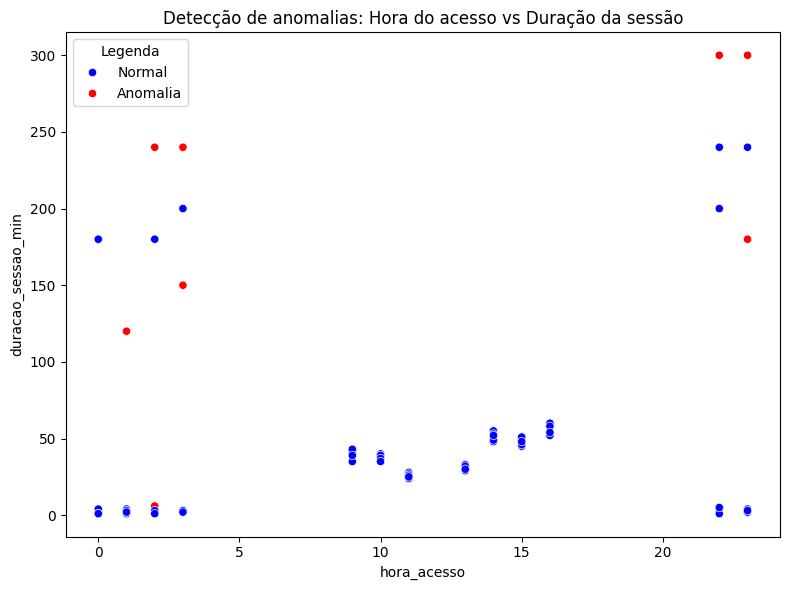

In [20]:
# 6 - Visualização dos Resultados

# Gráfico 1: Hora do acesso vs Duração da sessão
fig1, ax1 = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    x="hora_acesso", y="duracao_sessao_min", hue="Legenda",
    data=df, palette={"Normal": "blue", "Anomalia": "red"}, ax=ax1
)
ax1.set_title("Detecção de anomalias: Hora do acesso vs Duração da sessão")
plt.tight_layout()
plt.show("grafico_hora_vs_duracao.png")
plt.close()


##Analise critica do grafico:

A maioria das anomalias possuem poucas horas de acesso, com uma duração da sessão maior.

Usuários normais costumam acessar o sistema em horários comerciais e navegar por poucas páginas.

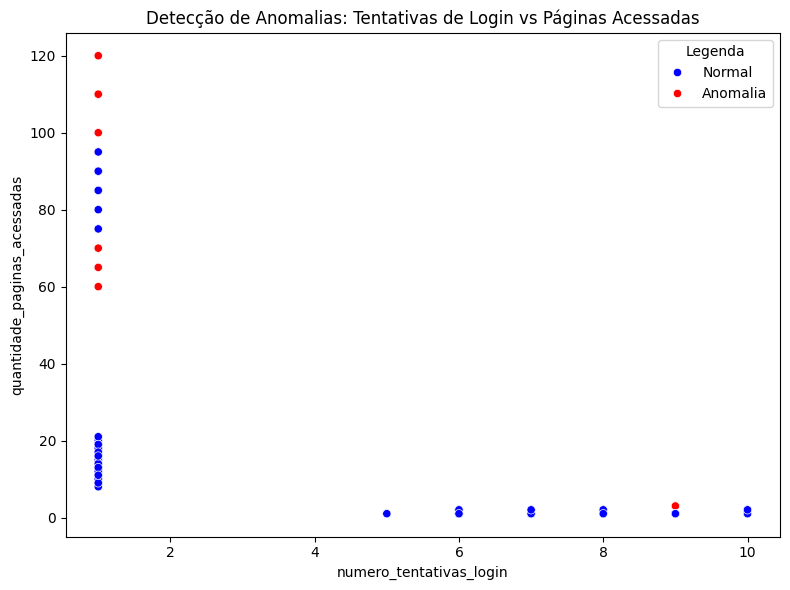

In [21]:
# Gráfico 2: Tentativas de login vs Páginas acessadas
fig2, ax2 = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    x="numero_tentativas_login", y="quantidade_paginas_acessadas", hue="Legenda",
    data=df, palette={"Normal": "blue", "Anomalia": "red"}, ax=ax2
)

ax2.set_title("Detecção de Anomalias: Tentativas de login vs Páginas acessadas")
plt.tight_layout()
plt.show("grafico_tentativas_vs_paginas.png")
plt.close()

df.to_csv("acessos_sistema_anomalies.csv", index=False)

##Analise critica do grafico:

Houve um movimento estranho quando percebemos que as anomalias possuem um número de tentativas de login baixa e uma quantidade bem expressiva de paginas acessadas..

Não sendo um número normal de uma pessoa no tempo hábil.

#Análise Geral -

Um usuário/anomalia tentou fazer login às 2h da manhã, realizou 9 tentativas de login, vindo de um IP não habitual, analisando o database e navegou por apenas 3 páginas em uma sessão curtíssima de 6 minutos.

-> Esse comportamento é um forte indicativo de um ataque automatizado ou manual tentando adivinhar credenciais fora do horário comercial a partir de uma localização geográfica desconhecida.

Houve acessos ocorrendo de madrugada, todos originados de IPs diferentes do habitual, com durações de sessão extremamente longas de acordo com o grafico e um volume grande de páginas acessadas.

-> Sessões de 5 horas consecutivas de madrugada baixando/acessando mais de 100 páginas a partir de IPs atípicos indicam ações de web scraping não autorizado ou exfiltração de dados confidenciais por um atacante ou funcionário mal-intencionado.